# Funnel Analysis on dataset

### Set-up

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Corporate Styling

In [3]:
plt.style.use('seaborn-v0_8-talk')
sns.set_palette('husl')

print("Everything is fine")

Everything is fine


### Load Dataset

In [9]:
from pathlib import Path
import pandas as pd

file_path = Path(r"G:\DA Projects\Python Projects\Funnel_Analysis\Dataset\funnel_analysis_data.csv")

df = pd.read_csv(file_path)

df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No


### Perform basic steps

In [10]:
print("Top 5 data\n")
display(df.head())

Top 5 data



,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No


In [11]:
# Last 5 row
df.tail()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
21658,USR09999,SES09999,Browse,2025-10-03 17:22:58,Desktop,South,Google Ads,Electronics,0.00,No
21659,USR09999,SES09999,Add to Cart,2025-10-03 17:26:58,Tablet,West,Social Media,Fashion,0.00,No
21660,USR09999,SES09999,Checkout,2025-10-03 17:29:58,Mobile,North,Email,Fashion,0.00,No
21661,USR09999,SES09999,Purchase,2025-10-03 17:34:58,Mobile,East,Email,Fashion,960.65,No
21662,USR10000,SES10000,Browse,2025-10-15 20:32:43,Mobile,South,Google Ads,Beauty,0.00,Yes


In [15]:
# Random data from dataset
df.sample()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
21310,USR09829,SES09829,Browse,2025-10-25 02:57:57,Tablet,East,Google Ads,Beauty,0.0,No


In [17]:
# Find total columns name and number of columns
print(df.columns)
print(f"\nTotal Number of Columns :- {df.columns.nunique()}")

Index(['User_ID', 'Session_ID', 'Event', 'Timestamp', 'Device', 'Region',
       'Channel', 'Product_Category', 'Revenue', 'Bounce_Flag'],
      dtype='object')

Total Number of Columns :- 10


In [18]:
# Type of dataset
type(df)

pandas.core.frame.DataFrame

In [21]:
# Type of all columns
df.dtypes

User_ID              object
Session_ID           object
Event                object
Timestamp            object
Device               object
Region               object
Channel              object
Product_Category     object
Revenue             float64
Bounce_Flag          object
dtype: object

In [22]:
# Timestamp column must be in date time format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(df.dtypes)

User_ID                     object
Session_ID                  object
Event                       object
Timestamp           datetime64[ns]
Device                      object
Region                      object
Channel                     object
Product_Category            object
Revenue                    float64
Bounce_Flag                 object
dtype: object


In [23]:
# Information about all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21663 entries, 0 to 21662
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           21663 non-null  object        
 1   Session_ID        21663 non-null  object        
 2   Event             21663 non-null  object        
 3   Timestamp         21663 non-null  datetime64[ns]
 4   Device            21663 non-null  object        
 5   Region            21663 non-null  object        
 6   Channel           21663 non-null  object        
 7   Product_Category  21663 non-null  object        
 8   Revenue           21663 non-null  float64       
 9   Bounce_Flag       21663 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(8)
memory usage: 1.7+ MB


In [24]:
# Important information about dataset's numeric columns
df.describe()

,Timestamp,Revenue
count,21663,21663.000000
mean,2025-10-16 19:56:22.920740608,54.304841
min,2025-10-01 19:30:17,0.000000
25%,2025-10-09 08:31:38,0.000000
50%,2025-10-16 19:47:21,0.000000
75%,2025-10-24 08:13:17,0.000000
max,2025-10-31 19:25:15,1998.510000
std,NaN,262.692471


In [25]:
# Important information abuot all columns
df.describe(include = "object")

,User_ID,Session_ID,Event,Device,Region,Channel,Product_Category,Bounce_Flag
count,21663,21663,21663,21663,21663,21663,21663,21663
unique,10000,10000,4,3,4,4,5,2
top,USR07731,SES07731,Browse,Tablet,West,Google Ads,Electronics,Yes
freq,4,4,10000,7237,5462,5435,4405,17343


In [27]:
# Shape of dataset
df.shape

(21663, 10)

In [28]:
pd.set_option("display.max_rows",None)

# Data Processing and Cleaning

In [31]:
# Check for null and duplicate vaues

print("\n----Finding Null Values----\n")
null_values = df.isnull().sum()
print(null_values)

print("\n----Finding Duplicate Values----\n")
duplicate_values = df.duplicated().sum()
print(f"Total number of duplicate values in this dataset is {duplicate_values}")

print("\n----Total Unique Data----\n")
unique_data = df.nunique()
print(unique_data)


----Finding Null Values----

User_ID             0
Session_ID          0
Event               0
Timestamp           0
Device              0
Region              0
Channel             0
Product_Category    0
Revenue             0
Bounce_Flag         0
dtype: int64

----Finding Duplicate Values----

Total number of duplicate values in this dataset is 0

----Total Unique Data----

User_ID             10000
Session_ID          10000
Event                   4
Timestamp           21564
Device                  3
Region                  4
Channel                 4
Product_Category        5
Revenue              1078
Bounce_Flag             2
dtype: int64


# FEATURE ENGINEERING

In [35]:
# ------------------------------------------
# Time-Based Features
# ------------------------------------------

# Extract date and time features

df['Date'] = df['Timestamp'].dt.date

df['Day_of_Week'] = df['Timestamp'].dt.day_name()

df['Hour'] = df['Timestamp'].dt.hour

df['Week_Number'] = df['Timestamp'].dt.isocalendar().week.astype(int)

# Sort events chronologically within each session

df = df.sort_values(
    by=['Session_ID', 'Timestamp']
).reset_index(drop=True)

# ------------------------------------------
# Event Sequence
# ------------------------------------------

df['Event_Sequence'] = (
    df.groupby('Session_ID').cumcount() + 1
)

# ------------------------------------------
# Time-Based Features
# ------------------------------------------

session_duration = (
    df.groupby('Session_ID')['Timestamp']
    .agg(['min','max'])
)

session_duration['Session_Duration_Minutes'] = (
    (session_duration['max'] - session_duration['min'])
    .dt.total_seconds() / 60
)

df = df.merge(
    session_duration['Session_Duration_Minutes'],
    left_on = 'Session_ID',
    right_index = True,
    how = 'left'
)

# ------------------------------------------
# Number of Events per Session
# ------------------------------------------

df['Events_Per_Session'] = (
    df.groupby('Session_ID')['Event']
    .transform('count')
)

print("Feature engineering completed successfully.")

df.head()

Feature engineering completed successfully.


,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Date,Day_of_Week,Hour,Week_Number,Event_Sequence,Session_Duration_Minutes,Events_Per_Session
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes,2025-10-28,Tuesday,7,44,1,7.0,3
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes,2025-10-28,Tuesday,7,44,2,7.0,3
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes,2025-10-28,Tuesday,7,44,3,7.0,3
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No,2025-10-19,Sunday,9,42,1,12.0,4
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No,2025-10-19,Sunday,9,42,2,12.0,4


In [38]:
# ==========================================
# SESSION-LEVEL DATASET
# ==========================================

session_df = (
    df.groupby('Session_ID')
    .agg(
        User_ID = ('User_ID', 'first'),
          Device=('Device', 'first'),
          Region=('Region', 'first'),
          Channel=('Channel', 'first'),
          Product_Category=('Product_Category', 'first'),
          Revenue=('Revenue', 'max'),
          Bounce_Flag=('Bounce_Flag', 'max'),
          Session_Duration_Minutes=('Session_Duration_Minutes', 'first'),
          Events_Per_Session=('Events_Per_Session', 'first'),
          Last_Event=('Event', 'last')
      )
      .reset_index()
)

# Purchase Indicatior
session_df['Purchased'] = (
    session_df['Last_Event'] == 'Purchase'
).astype(int)

session_df.head()

,Session_ID,User_ID,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Session_Duration_Minutes,Events_Per_Session,Last_Event,Purchased
0,SES00001,USR00001,Desktop,West,Organic,Home,0.00,Yes,7.0,3,Checkout,0
1,SES00002,USR00002,Desktop,East,Email,Electronics,448.18,No,12.0,4,Purchase,1
2,SES00003,USR00003,Desktop,East,Google Ads,Beauty,1437.19,No,10.0,4,Purchase,1
3,SES00004,USR00004,Tablet,West,Social Media,Home,0.00,Yes,0.0,1,Browse,0
4,SES00005,USR00005,Tablet,West,Google Ads,Electronics,0.00,Yes,2.0,2,Add to Cart,0


# Solving the Business Questions

Sessions at each funnel stage:
Event
Browse         10000
Add to Cart     7059
Checkout        3524
Purchase        1080
Name: Session_ID, dtype: int64


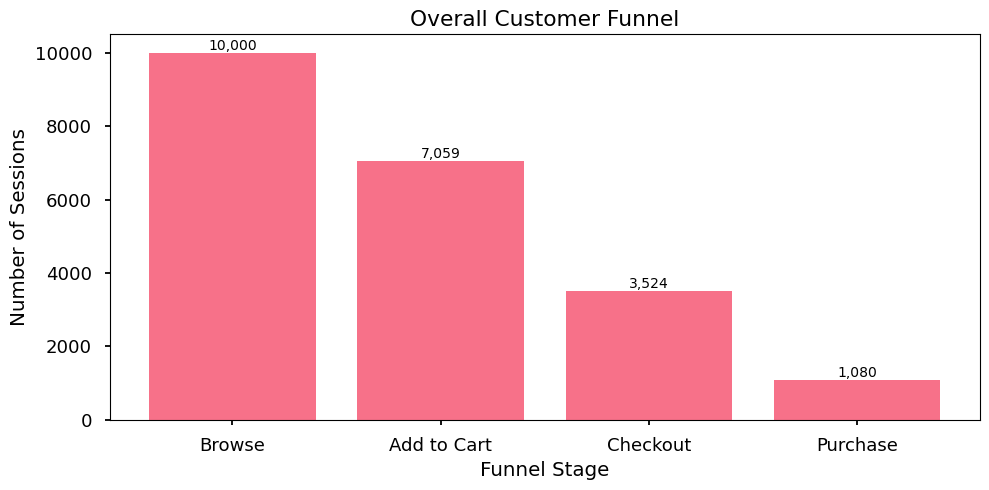

In [41]:
# ================================================================================================================
# Q1: OVERALL FUNNEL - What does the overall customer funnel look like, and how many sessions reach each stage?
# ================================================================================================================

funnel_order = [
    'Browse',
    'Add to Cart',
    'Checkout',
    'Purchase'
]

funnel_counts = (
    df[df['Event'].isin(funnel_order)]
    .groupby('Event')['Session_ID']
    .nunique()
    .reindex(funnel_order)
)

print("Sessions at each funnel stage:")
print(funnel_counts)

# ------------------------------------------
# Matplotlib
# ------------------------------------------

plt.figure(figsize = (10,5))

plt.bar(
    funnel_counts.index,
    funnel_counts.values
)

plt.title('Overall Customer Funnel')
plt.xlabel('Funnel Stage')
plt.ylabel('Number of Sessions')

for i, value in enumerate(funnel_counts.values):
    plt.text(
        i,
        value,
        f'{value:,}',
        ha = 'center',
        va = 'bottom'
    )

plt.tight_layout()
plt.show()

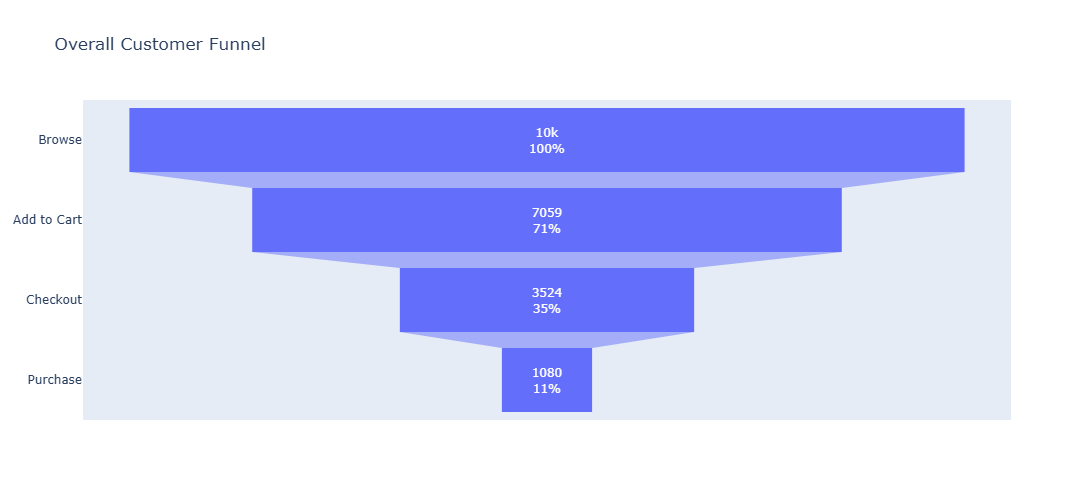

In [44]:
# ==========================================
# INTERACTIVE FUNNEL - PLOTLY
# ==========================================

fig = go.Figure(
    go.Funnel(
        y=funnel_counts.index,
        x=funnel_counts.values,
        textinfo="value+percent initial"
    )
)

fig.update_layout(
    title='Overall Customer Funnel',
    height=500
)

fig.show()

             Sessions  Stage_Conversion_%  Drop-Off_%  Overall_Conversion_%
Event                                                                      
Browse          10000                 NaN         NaN                100.00
Add to Cart      7059               70.59       29.41                 70.59
Checkout         3524               49.92       50.08                 35.24
Purchase         1080               30.65       69.35                 10.80


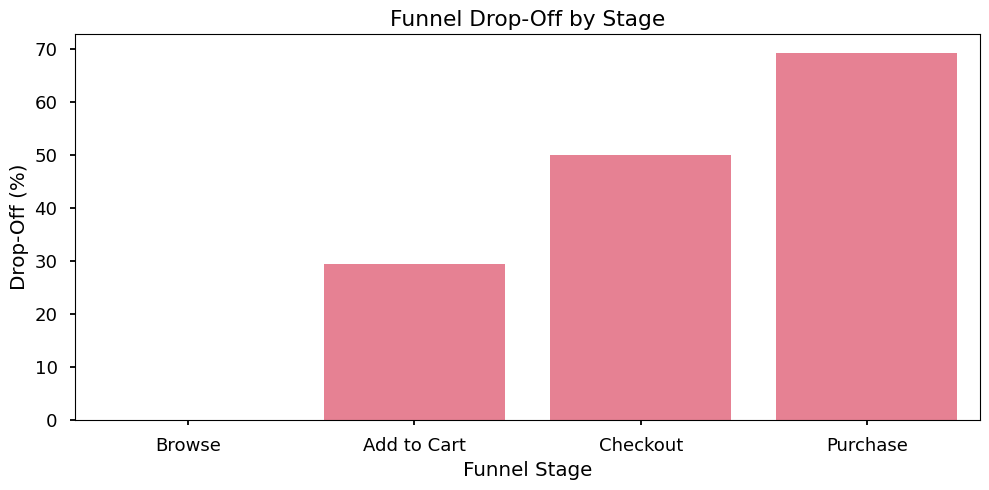

In [45]:
# ==========================================================================
# Q2: FUNNEL CONVERSION & DROP-OFF -- Where is the biggest funnel drop-off, 
# and what percentage of users are lost at each stage?
# ==========================================================================

funnel_analysis = pd.DataFrame({
    'Sessions' : funnel_counts
})

funnel_analysis['Stage_Conversion_%'] = (
    funnel_analysis['Sessions']
    .div(funnel_analysis['Sessions'].shift(1))
    .mul(100)
)

funnel_analysis['Drop-Off_%'] = (
    100 - funnel_analysis['Stage_Conversion_%']
)

# Overall conversion from Browse
funnel_analysis['Overall_Conversion_%'] = (
    funnel_analysis['Sessions']
    .div(funnel_analysis['Sessions'].iloc[0])
    .mul(100)
)

print(funnel_analysis.round(2))

# ------------------------------------------
# Seaborn visualization
# ------------------------------------------

plt.figure(figsize = (10,5))

sns.barplot(
    data = funnel_analysis.reset_index(),
    x = 'Event',
    y = 'Drop-Off_%'
)

plt.title('Funnel Drop-Off by Stage')
plt.xlabel('Funnel Stage')
plt.ylabel('Drop-Off (%)')

plt.tight_layout()
plt.show()

In [47]:
# Identify the largest drop-off

largest_drop = (
    funnel_analysis['Drop-Off_%']
    .iloc[1:]
    .idxmax()
)

largest_drop_value = (
    funnel_analysis.loc[largest_drop, 'Drop-Off_%']
)

print(
    f"Largest drop-off occurs at: {largest_drop} "
    f"({largest_drop_value:.2f}%)"
)

Largest drop-off occurs at: Purchase (69.35%)


Event         Browse  Add to Cart  Checkout  Purchase  Browse_to_Purchase_%
Channel                                                                    
Email           2489         1788       877       279                 11.21
Google Ads      2560         1708       888       279                 10.90
Social Media    2440         1809       898       265                 10.86
Organic         2511         1754       861       257                 10.23


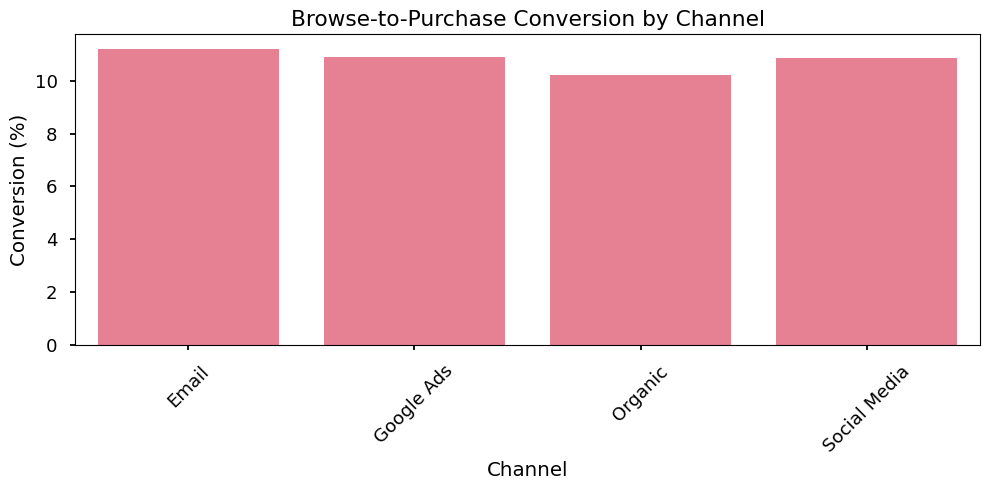

In [51]:
# =====================================================================================================================
# Q3: CHANNEL FUNNEL PERFORMANCE - Which acquisition channel converts browsing sessions into purchases most effectively?
# =====================================================================================================================

channel_funnel = (
    df[df['Event'].isin(funnel_order)]
    .groupby(['Channel', 'Event'])['Session_ID']
    .nunique()
    .unstack(fill_value=0)
)

channel_funnel = channel_funnel.reindex(
    columns = funnel_order,
    fill_value = 0
)

# Conversion from Browse to Purchase

channel_funnel['Browse_to_Purchase_%'] = (
    channel_funnel['Purchase']
    / channel_funnel['Browse']
    * 100
)

print(
    channel_funnel
    .sort_values('Browse_to_Purchase_%', ascending = False)
    .round(2)
)

# ------------------------------------------
# Seaborn
# ------------------------------------------

plt.figure(figsize = (10,5))

sns.barplot(
    data = channel_funnel.reset_index(),
    x = 'Channel',
    y = 'Browse_to_Purchase_%'
)

plt.title('Browse-to-Purchase Conversion by Channel')
plt.xlabel('Channel')
plt.ylabel('Conversion (%)')

plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

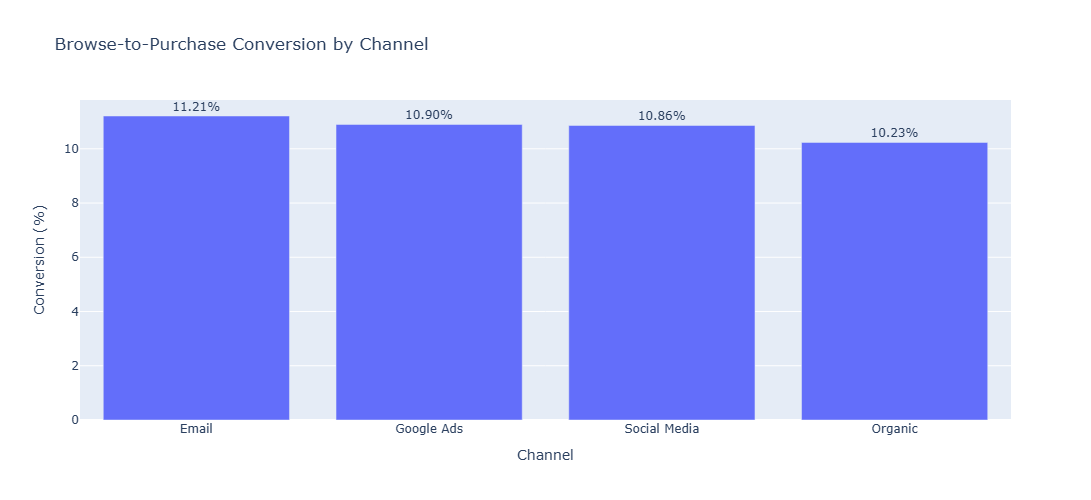

In [62]:
# ==========================================
# PLOTLY CHANNEL CONVERSION
# ==========================================

plot_df = (
    channel_funnel['Browse_to_Purchase_%']
    .sort_values(ascending = False)
    .reset_index()
)

fig = px.bar(
    plot_df,
    x = 'Channel',
    y = 'Browse_to_Purchase_%',
    text = 'Browse_to_Purchase_%',
    title = 'Browse-to-Purchase Conversion by Channel'
)

fig.update_traces(
    texttemplate = '%{text:.2f}%',
    textposition = 'outside'
)

fig.update_layout(
    yaxis_title = 'Conversion (%)',
    xaxis_title='Channel',
    width = 1000,
    height = 500
)

fig.show()

              Sessions  Purchases    Revenue  Conversion_%  \
Channel                                                      
Google Ads        2560        282  312769.26          0.09   
Organic           2511        281  307448.35          0.09   
Social Media      2440        263  280071.63          0.09   
Email             2489        254  276116.54          0.09   

              Revenue_per_Session  
Channel                            
Google Ads                 122.18  
Organic                    122.44  
Social Media               114.78  
Email                      110.93  


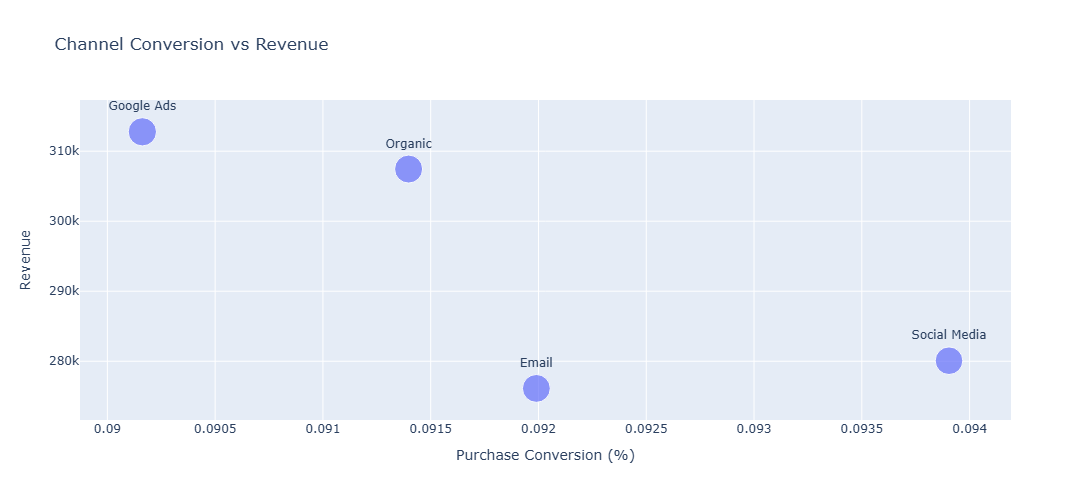

In [64]:
# =========================================================================================
# Q4: CHANNEL REVENUE VS CONVERSION - Which acquisition channels generate the most revenue, 
#and does higher conversion translate into higher revenue?
# =========================================================================================

channel_performance = (
    session_df
    .groupby('Channel')
    .agg(
        Sessions = ('Session_ID','nunique'),
        Purchases = ('Purchased','sum'),
        Revenue = ('Revenue','sum')
    )
)

channel_performance['Conversion_%'] = (
    channel_performance['Purchases']
    /channel_performance['Revenue']
    *100
)

channel_performance['Revenue_per_Session'] = (
    channel_performance['Revenue']
    /channel_performance['Sessions']
)

print(
    channel_performance
    .sort_values('Revenue', ascending = False)
    .round(2)
)

# ------------------------------------------
# Plotly
# ------------------------------------------

fig = px.scatter(
    channel_performance.reset_index(),
    x = 'Conversion_%',
    y = 'Revenue',
    size = 'Sessions',
    text = 'Channel',
    title = 'Channel Conversion vs Revenue'
)

fig.update_traces(
    textposition = 'top center'
)

fig.update_layout(
    xaxis_title = 'Purchase Conversion (%)',
    yaxis_title = 'Revenue',
    width = 1000,
    height = 500
)

fig.show()

Event    Browse  Add to Cart  Checkout  Purchase  Browse_to_Add_to_Cart_%  \
Device                                                                      
Desktop    3331         2399      1177       328                    72.02   
Mobile     3345         2329      1148       369                    69.63   
Tablet     3324         2331      1199       383                    70.13   

Event    Add_to_Cart_to_Checkout_%  Checkout_to_Purchase_%  \
Device                                                       
Desktop                      49.06                   27.87   
Mobile                       49.29                   32.14   
Tablet                       51.44                   31.94   

Event    Overall_Conversion_%  
Device                         
Desktop                  9.85  
Mobile                  11.03  
Tablet                  11.52  


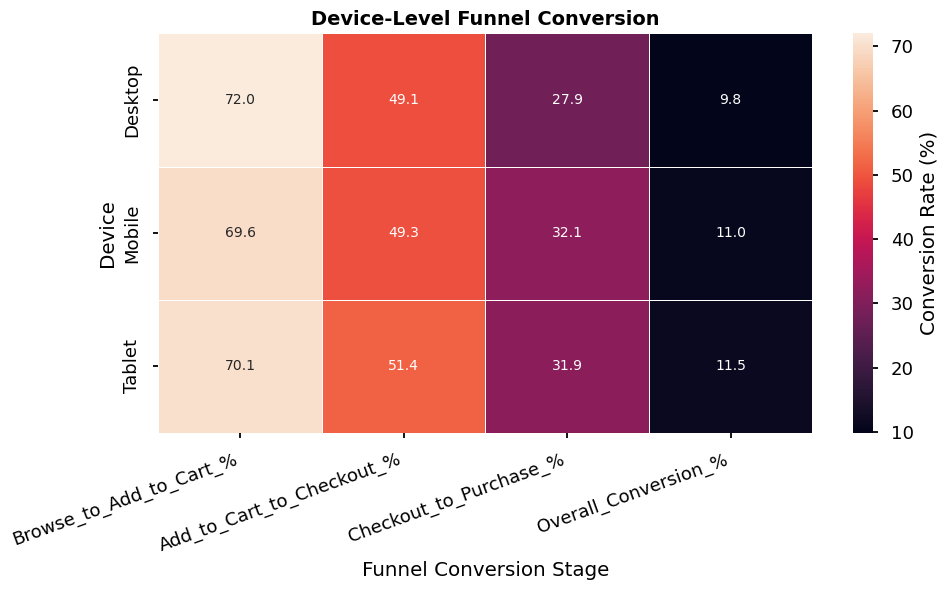

In [71]:
# ============================================================================
# Q5: DEVICE FUNNEL PERFORMANCE - Which device has the biggest funnel problem?
# =============================================================================

# ------------------------------------------
# Device-Level Funnel Analysis
# ------------------------------------------

device_funnel = (
    df[df['Event'].isin(funnel_order)]
    .groupby(['Device', 'Event'])['Session_ID']
    .nunique()
    .unstack(fill_value=0)
)

# Ensure funnel stages appear in the correct order
device_funnel = device_funnel.reindex(
    columns=funnel_order,
    fill_value=0
)

# ------------------------------------------
# Stage-to-Stage Conversion
# ------------------------------------------

for i in range(1, len(funnel_order)):

    previous_stage = funnel_order[i - 1]
    current_stage = funnel_order[i]

    # Create clean column names
    previous_clean = previous_stage.replace(' ', '_')
    current_clean = current_stage.replace(' ', '_')

    device_funnel[
        f'{previous_clean}_to_{current_clean}_%'
    ] = (
        device_funnel[current_stage]
        .div(device_funnel[previous_stage].replace(0, pd.NA))
        .mul(100)
    )

# ------------------------------------------
# Overall Conversion
# ------------------------------------------

device_funnel['Overall_Conversion_%'] = (
    device_funnel['Purchase']
    .div(device_funnel['Browse'].replace(0, pd.NA))
    .mul(100)
)

# Round for display
print(device_funnel.round(2))


# ------------------------------------------
# Conversion Heatmap
# ------------------------------------------

heatmap_data = device_funnel[
    [
        "Browse_to_Add_to_Cart_%",
        "Add_to_Cart_to_Checkout_%",
        "Checkout_to_Purchase_%",
        "Overall_Conversion_%"
    ]
]

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={'label': 'Conversion Rate (%)'}
)

plt.title(
    'Device-Level Funnel Conversion',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Funnel Conversion Stage')
plt.ylabel('Device')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

        Sessions  Purchases    Revenue  Conversion_%
Region                                              
South       2506        282  311018.57         11.25
East        2514        280  301767.14         11.14
North       2504        261  288027.95         10.42
West        2476        257  275592.12         10.38


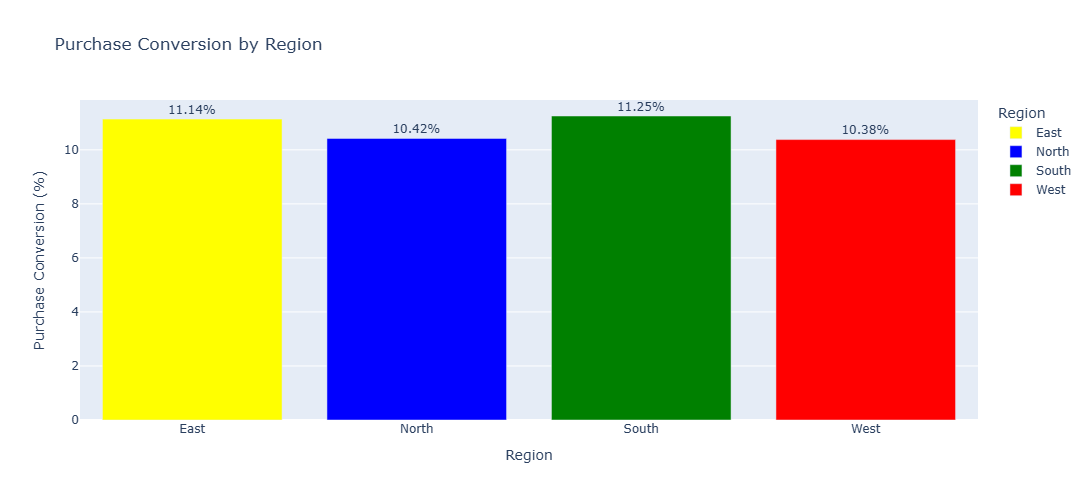

In [83]:
# ==================================================================================================
# Q6: REGIONAL FUNNEL PERFORMANCE - Which region has the strongest and weakest purchase conversion?
# ==================================================================================================

regional_performance = (
    session_df
    .groupby('Region')
    .agg(
        Sessions = ('Session_ID', 'nunique'),
        Purchases = ('Purchased','sum'),
        Revenue = ('Revenue','sum')
    )
)

regional_performance['Conversion_%'] = (
    regional_performance['Purchases']
    /regional_performance['Sessions']
    *100
)

print(
    regional_performance
    .sort_values('Conversion_%', ascending = False)
    .round(2)
)

# ------------------------------------------
# Plotly
# ------------------------------------------

fig = px.bar(
    regional_performance.reset_index(),
    x = 'Region',
    y = 'Conversion_%',
    text = 'Conversion_%',
    title = 'Purchase Conversion by Region',
    color="Region",
    color_discrete_map={
        "South": "green",
        "East": "yellow",
        "North": "blue",
        "West": "red"
    }
)

fig.update_traces(
    texttemplate = '%{text:.2f}%',
    textposition = 'outside'
)

fig.update_layout(
    yaxis_title='Purchase Conversion (%)',
    xaxis_title = 'Region',
    width = 1000,
    height = 500
)

fig.show()

Event             Browse  Add to Cart  Checkout  Purchase  Add_to_Cart_Rate_%  \
Product_Category                                                                
Beauty              1978         1402       699       201               70.88   
Electronics         2046         1444       686       229               70.58   
Fashion             2035         1435       707       223               70.52   
Home                1941         1341       736       212               69.09   
Sports              2000         1437       696       215               71.85   

Event             Checkout_Rate_%  Purchase_Conversion_%  
Product_Category                                          
Beauty                      35.34                  10.16  
Electronics                 33.53                  11.19  
Fashion                     34.74                  10.96  
Home                        37.92                  10.92  
Sports                      34.80                  10.75  


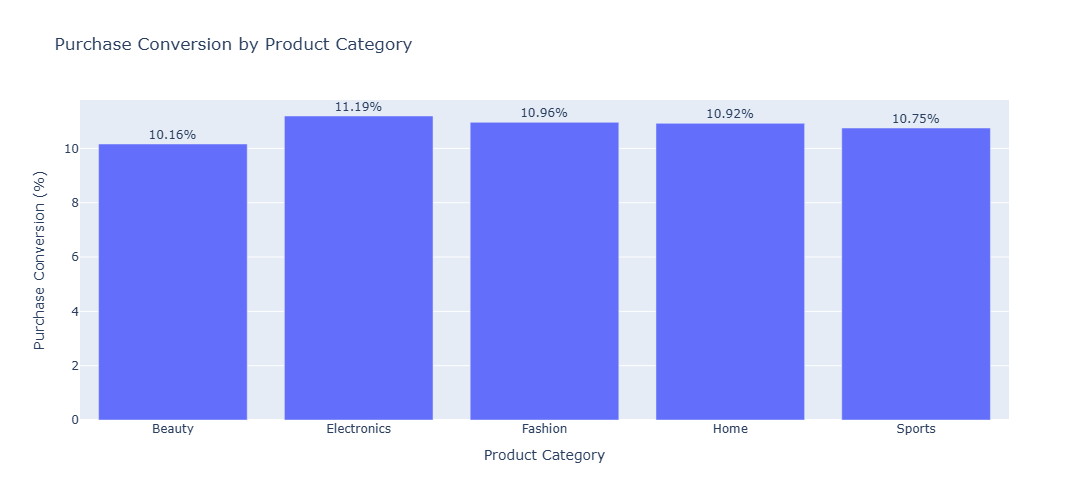

In [90]:
# ==================================================================================================================
# Q7: PRODUCT CATEGORY FUNNEL - Which product categories attract users but struggle to convert them into purchases?
# ==================================================================================================================

category_funnel = (
    df[df['Event'].isin(funnel_order)]
    .groupby(['Product_Category', 'Event'])['Session_ID']
    .nunique()
    .unstack(fill_value = 0)
)

category_funnel = category_funnel.reindex(
    columns = funnel_order,
    fill_value = 0
)

category_funnel['Add_to_Cart_Rate_%'] = (
    category_funnel['Add to Cart']
    / category_funnel['Browse']
    * 100
)

category_funnel['Checkout_Rate_%'] = (
    category_funnel['Checkout']
    / category_funnel['Browse']
    * 100
)

category_funnel['Purchase_Conversion_%'] = (
    category_funnel['Purchase']
    / category_funnel['Browse']
    * 100
)

print(
    category_funnel[
        [
        'Browse',
        'Add to Cart',
        'Checkout',
        'Purchase',
        'Add_to_Cart_Rate_%',
        'Checkout_Rate_%',
        'Purchase_Conversion_%'
        ]
    ].round(2)
)

# ------------------------------------------
# Plotly
# ------------------------------------------

fig = px.bar(
    category_funnel.reset_index(),
    x = 'Product_Category',
    y = 'Purchase_Conversion_%',
    text = 'Purchase_Conversion_%',
    title = 'Purchase Conversion by Product Category'
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    yaxis_title='Purchase Conversion (%)',
    xaxis_title = 'Product Category',
    width = 1000,
    height = 500
)

fig.show()      

Event        Add to Cart  Browse  Checkout  Purchase  Conversion_%
Day_of_Week                                                       
Monday               942    1339       459       160         11.95
Tuesday              941    1339       470       126          9.41
Wednesday            956    1370       462       133          9.71
Thursday            1159    1643       595       181         11.02
Friday              1117    1558       565       166         10.65
Saturday             965    1387       495       153         11.03
Sunday               979    1364       478       161         11.80


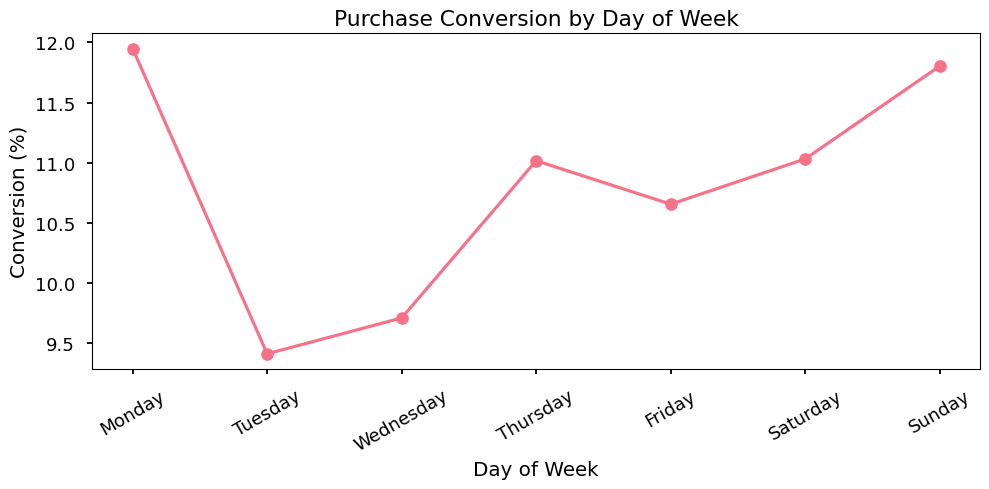

In [97]:
# ======================================================================================
# Q8: DAY-OF-WEEK FUNNEL PERFORMANCE - Does funnel performance vary by day of the week?
# ======================================================================================

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_performance = (
    df[df['Event'].isin(funnel_order)]
    .groupby(['Day_of_Week', 'Event'])['Session_ID']
    .nunique()
    .unstack(fill_value=0)
)

day_performance = day_performance.reindex(day_order)

day_performance['Conversion_%'] = (
    day_performance['Purchase']
    / day_performance['Browse']
    * 100
)

print(day_performance.round(2))

# ------------------------------------------
# Matplotlib
# ------------------------------------------

plt.figure(figsize = (10,5))

plt.plot(
    day_performance.index,
    day_performance['Conversion_%'],
    marker = 'o'
)

plt.title('Purchase Conversion by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Conversion (%)')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()       

Hourly Funnel Performance:


,Sessions,Purchases,Conversion_%
Entry_Hour,,,
0,391,47,12.02
1,432,54,12.50
2,424,38,8.96
3,351,45,12.82
4,425,44,10.35
5,414,38,9.18
6,429,39,9.09
7,454,51,11.23
8,412,44,10.68


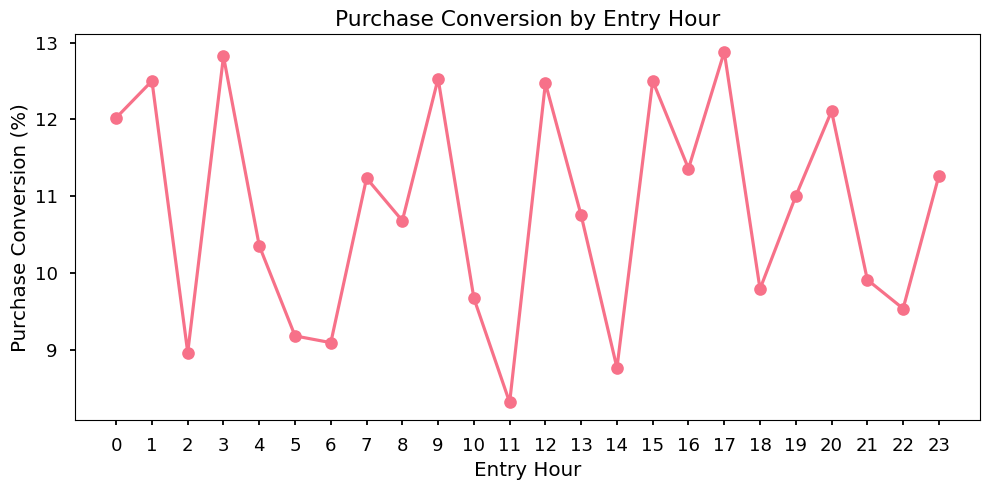

In [99]:
# ===============================================================================
# Q9: HOURLY FUNNEL PERFORMANCE - What are the peak hours for customer activity, 
# and do those hours actually produce purchases?
# ===============================================================================

# Get the first event/hour for each session
hourly_sessions = (
    df.sort_values(['Session_ID', 'Timestamp'])
      .groupby('Session_ID')
      .agg(
          Entry_Hour=('Hour', 'first')
      )
      .reset_index()
)

# Add purchase information
hourly_sessions = hourly_sessions.merge(
    session_df[['Session_ID', 'Purchased']],
    on='Session_ID',
    how='left'
)

# Calculate hourly performance
hourly_performance = (
    hourly_sessions
    .groupby('Entry_Hour')
    .agg(
        Sessions=('Session_ID', 'nunique'),
        Purchases=('Purchased', 'sum')
    )
)

# Calculate conversion rate
hourly_performance['Conversion_%'] = (
    hourly_performance['Purchases']
    / hourly_performance['Sessions']
    * 100
)

print("Hourly Funnel Performance:")
display(hourly_performance.round(2))


# ==========================================
# MATPLOTLIB VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_performance.index,
    hourly_performance['Conversion_%'],
    marker='o'
)

plt.title('Purchase Conversion by Entry Hour')
plt.xlabel('Entry Hour')
plt.ylabel('Purchase Conversion (%)')

plt.xticks(range(24))
plt.grid(False)

plt.tight_layout()
plt.show()

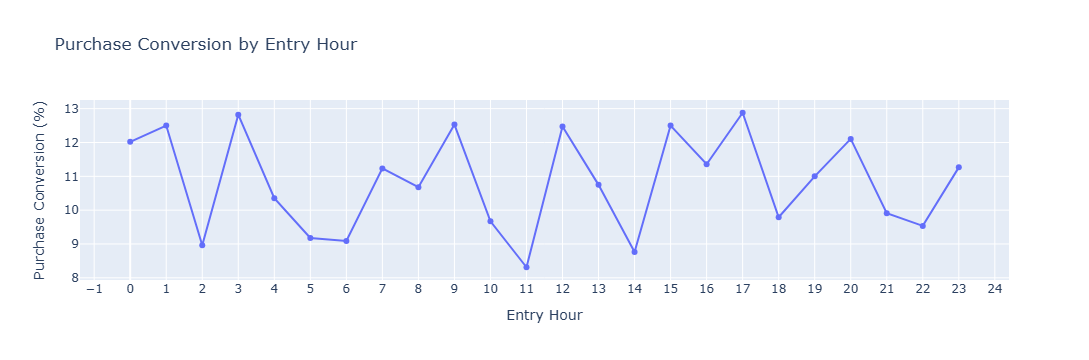

In [100]:
# ==========================================
# PLOTLY VISUALIZATION
# ==========================================

plotly_hourly = hourly_performance.reset_index()

fig = px.line(
    plotly_hourly,
    x='Entry_Hour',
    y='Conversion_%',
    markers=True,
    title='Purchase Conversion by Entry Hour'
)

fig.update_layout(
    xaxis=dict(
        dtick=1,
        title='Entry Hour'
    ),
    yaxis_title='Purchase Conversion (%)'
)

fig.show()

In [103]:
# ==========================================
# CONVERT BOUNCE FLAG TO NUMERIC
# ==========================================

df['Bounce_Flag'] = (
    df['Bounce_Flag']
    .map({'Yes': 1, 'No': 0})
)

# Check the conversion
print(df['Bounce_Flag'].value_counts(dropna=False))

Bounce_Flag
1    17343
0     4320
Name: count, dtype: int64


In [104]:
# ==========================================
# RECREATE SESSION-LEVEL DATASET
# ==========================================

session_df = (
    df.groupby('Session_ID')
      .agg(
          User_ID=('User_ID', 'first'),
          Device=('Device', 'first'),
          Region=('Region', 'first'),
          Channel=('Channel', 'first'),
          Product_Category=('Product_Category', 'first'),
          Revenue=('Revenue', 'max'),
          Bounce_Flag=('Bounce_Flag', 'max'),
          Session_Duration_Minutes=('Session_Duration_Minutes', 'first'),
          Events_Per_Session=('Events_Per_Session', 'first'),
          Last_Event=('Event', 'last')
      )
      .reset_index()
)

# Purchase indicator
session_df['Purchased'] = (
    session_df['Last_Event'] == 'Purchase'
).astype(int)

session_df.head()

,Session_ID,User_ID,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Session_Duration_Minutes,Events_Per_Session,Last_Event,Purchased
0,SES00001,USR00001,Desktop,West,Organic,Home,0.00,1,7.0,3,Checkout,0
1,SES00002,USR00002,Desktop,East,Email,Electronics,448.18,0,12.0,4,Purchase,1
2,SES00003,USR00003,Desktop,East,Google Ads,Beauty,1437.19,0,10.0,4,Purchase,1
3,SES00004,USR00004,Tablet,West,Social Media,Home,0.00,1,0.0,1,Browse,0
4,SES00005,USR00005,Tablet,West,Google Ads,Electronics,0.00,1,2.0,2,Add to Cart,0


Overall Bounce Rate: 89.20%

Bounce Rate by Channel:
Channel
Email           89.80
Social Media    89.22
Google Ads      88.98
Organic         88.81
Name: Bounce_Flag, dtype: float64

Bounce Rate by Device:
Device
Tablet     89.62
Mobile     89.15
Desktop    88.83
Name: Bounce_Flag, dtype: float64


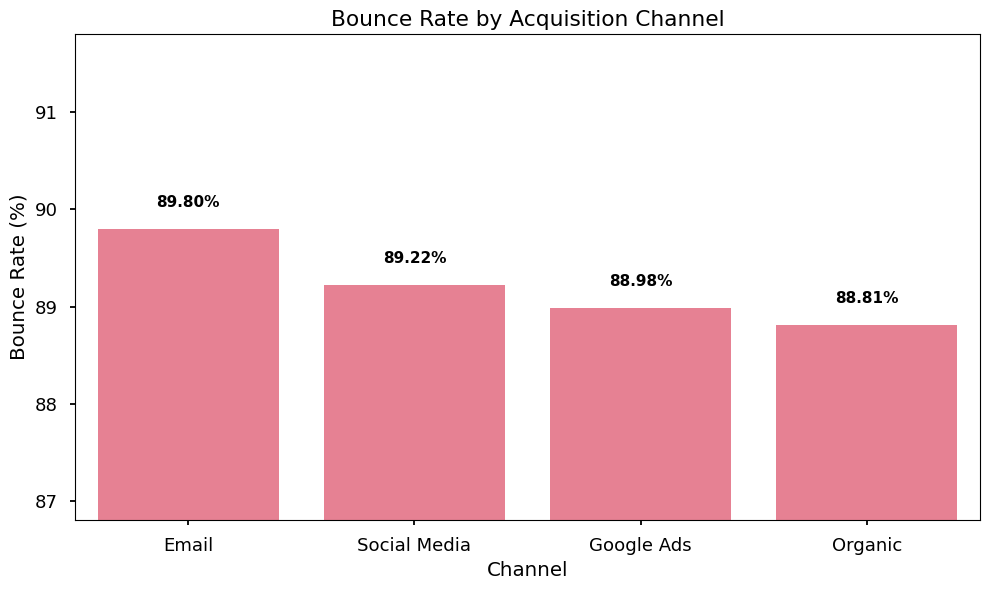

In [107]:
# ===========================================================================
# Q10: BOUNCE ANALYSIS - How does bounce behavior affect funnel progression, 
#and which segments have the highest bounce rate?
# ===========================================================================

# Overall Bounce Rate

overall_bounce_rate = (
    session_df['Bounce_Flag'].mean() * 100
)

print(
    f"Overall Bounce Rate: {overall_bounce_rate:.2f}%"
)

# ------------------------------------------
# Bounce by Channel
# ------------------------------------------

bounce_channel = (
    session_df
    .groupby('Channel')['Bounce_Flag']
    .mean()
    .mul(100)
    .sort_values(ascending = False)
)

print("\nBounce Rate by Channel:")
print(bounce_channel.round(2))

# ------------------------------------------
# Bounce by Device
# ------------------------------------------

bounce_device = (
    session_df
    .groupby('Device')['Bounce_Flag']
    .mean()
    .mul(100)
    .sort_values(ascending = False)
)

print("\nBounce Rate by Device:")
print(bounce_device.round(2))

# ==========================================
# RANKED BOUNCE RATE VISUALIZATION
# ==========================================

bounce_channel = bounce_channel.sort_values(ascending=False)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=bounce_channel.index,
    y=bounce_channel.values
)

plt.title('Bounce Rate by Acquisition Channel')
plt.xlabel('Channel')
plt.ylabel('Bounce Rate (%)')

plt.ylim(
    bounce_channel.min() - 2,
    bounce_channel.max() + 2
)

for i, value in enumerate(bounce_channel.values):
    ax.text(
        i,
        value + 0.2,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(False)
plt.tight_layout()
plt.show()

                 Sessions  Purchases  Conversion_%
Duration_Bucket                                   
0–1 min              2941          0          0.00
1–5 min              3950          0          0.00
5–10 min             2566        537         20.93
10–20 min             543        543        100.00


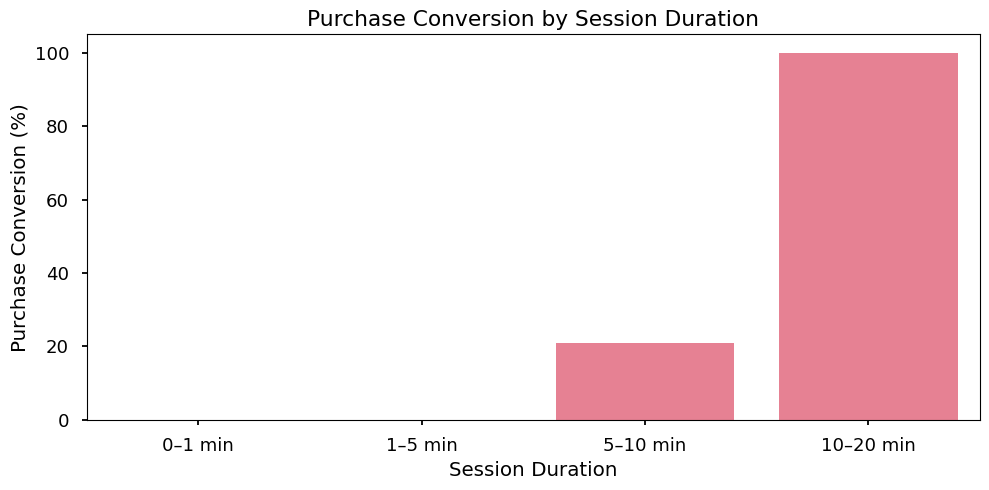

In [115]:
# =============================================================================================
# Q11: SESSION DURATION VS CONVERSION - Do longer sessions lead to higher purchase conversion?
# =============================================================================================

duration_bins = [
    -1,
    1,
    5,
    10,
    float('inf')
]

duration_labels = [
    '0–1 min',
    '1–5 min',
    '5–10 min',
    '10–20 min',
]

session_df['Duration_Bucket'] = pd.cut(
    session_df['Session_Duration_Minutes'],
    bins = duration_bins,
    labels = duration_labels
)

duration_performance = (
    session_df
    .groupby('Duration_Bucket',observed = False)
    .agg(
        Sessions = ('Session_ID','nunique'),
        Purchases = ('Purchased','sum')
    )
)

duration_performance['Conversion_%'] = (
    duration_performance['Purchases']
    /duration_performance['Sessions']
    *100
)

print(duration_performance.round(2))

# ------------------------------------------
# Seaborn
# ------------------------------------------

plt.figure(figsize = (10,5))

sns.barplot(
    data = duration_performance.reset_index(),
    x = 'Duration_Bucket',
    y = 'Conversion_%'
)

plt.title('Purchase Conversion by Session Duration')
plt.xlabel('Session Duration')
plt.ylabel('Purchase Conversion (%)')

plt.tight_layout()
plt.show()   

Top 10 Customer Journey Paths:
Event
Browse→Add to Cart                      3535
Browse                                  2941
Browse→Add to Cart→Checkout             2444
Browse→Add to Cart→Checkout→Purchase    1080
Name: count, dtype: int64


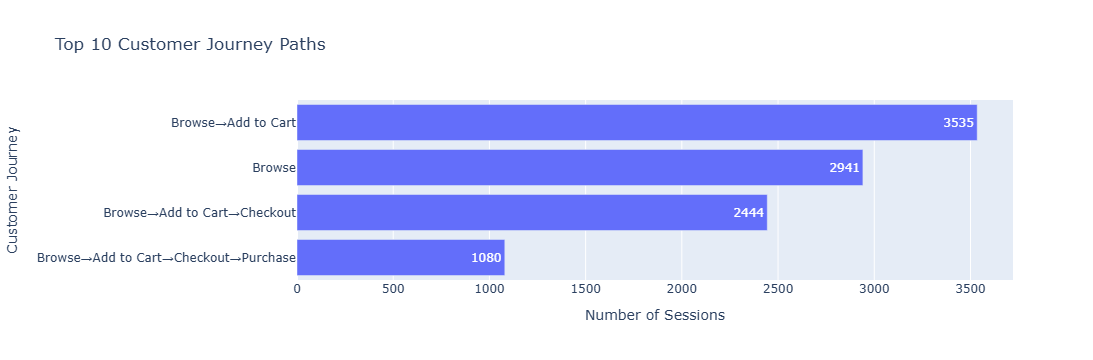

In [118]:
# ===============================================================================
# Q12: CUSTOMER JOURNEY PATHS - What are the most common customer journey paths, 
#and where do users abandon the funnel?
# ==============================================================================

journey_paths = (
    df.sort_values(['Session_ID', 'Timestamp'])
    .groupby('Session_ID')['Event']
    .agg('→'.join)
)

journey_counts = (
    journey_paths
    .value_counts()
    .head(10)
)

print("Top 10 Customer Journey Paths:")
print(journey_counts)

# ------------------------------------------
# Plotly
# ------------------------------------------

journey_plot = (
    journey_counts
    .sort_values()
    .reset_index()
)

journey_plot.columns = [
    'Journey_Path',
    'Sessions'
]

fig = px.bar(
    journey_plot,
    x = 'Sessions',
    y = 'Journey_Path',
    orientation = 'h',
    text = 'Sessions',
    title = 'Top 10 Customer Journey Paths'
)

fig.update_layout(
    yaxis_title = 'Customer Journey',
    xaxis_title= 'Number of Sessions'
)

fig.show()   

## 
##  ======================== Thank You! ============================